---

# **Module 5: Application of Artificial Intelligence in Real World**

This module focuses on moving from theoretical machine learning concepts to practical, scalable applications, covering everything from text processing to deploying models in the cloud.

---

## **Part I: Natural Language Processing (NLP)**

NLP is a field of AI that gives machines the ability to read, understand, and derive meaning from human languages.

### **(1 & 2) Topic Modeling and Sentiment Analysis**

*   **Topic Modeling**: An unsupervised technique to identify abstract "topics" that occur in a collection of documents. A common algorithm is **Latent Dirichlet Allocation (LDA)**.
*   **Sentiment Analysis**: The process of computationally identifying and categorizing opinions expressed in a piece of text, especially to determine the writer's attitude as positive, negative, or neutral.

### **(3) Fuzzy Logic**

Fuzzy Logic is a form of many-valued logic that deals with reasoning that is approximate rather than fixed and exact. Unlike Boolean logic (True/False, 1/0), it deals with degrees of truth. In NLP, it can be used for:
*   Spell checking and correction (matching words that are "almost" right).
*   String matching (e.g., matching "color" and "colour").
*   Handling imprecise or vague human language.

### **(4) NLTK (Natural Language Toolkit)**

A leading platform for building Python programs to work with human language data. It provides easy-to-use interfaces to over 50 corpora and lexical resources, along with a suite of text processing libraries.

### **(5) Spam Detection**

A classic binary classification problem where the goal is to classify a text (email, message) as "spam" (1) or "ham" (not spam, 0). It's often solved using NLP techniques to extract features from text. Primary Algorithm used for Spam Detection are: *Feature Extraction:* TF-IDF (preferred over Bag-of-Words), *Classifier:* Naive Bayes, Random Forest, SVM.


---

### **(1) Topic Modeling**

**What it is:**
Topic Modeling is an **unsupervised** machine learning technique for discovering abstract "topics" that occur in a collection of documents. It doesn't require pre-labeled data; the algorithm identifies patterns of word co-occurrence to group documents into themes.

*   **Key Algorithm:** **Latent Dirichlet Allocation (LDA)** is the most famous. It operates on three principles:
    1.  **Documents** are mixtures of **topics**. (e.g., a document could be 60% "Politics", 40% "Economics").
    2.  **Topics** are mixtures of **words**. (e.g., the "Politics" topic might contain words like: *election, vote, bill, senator, policy* with certain probabilities).
    3.  The algorithm reverse-engineers this structure to find the topics that best explain the patterns in the word usage.

**When to Use:**
*   When you have a large, unlabeled corpus of text and need to **discover its hidden thematic structure**.
*   For **exploratory data analysis** to understand the main themes in customer reviews, news articles, academic papers, etc.
*   To **organize, summarize, and tag** large archives of documents.

**Why Use it:**
It provides a high-level, interpretable summary of a massive amount of text that would be impossible for a human to read and categorize manually.

**Use Case Example:**
A news agency wants to automatically categorize millions of news articles into topics like "Sports," "Finance," "Entertainment," and "Politics" without having to hire an army of editors to tag them all.

**Python Implementation with LDA:**

In [ ]:
# Supressing the Future Warnings:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)  # Suppress all FutureWarnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)  # Suppress ConvergenceWarnings

In [23]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Sample Data: News Headlines
documents = [
    "Stock market hits all time high amid economic growth",
    "The new basketball season tips off with a thrilling overtime victory",
    "Parliament debates new climate change legislation",
    "Central bank announces interest rate decision tomorrow",
    "Star actor wins best award at international film festival",
    "Football transfer window closes with record signing",
    "Scientists publish new report on global warming effects",
    "Team wins national championship after a decade"
]

# Text Preprocessing & Vectorization (Create a Bag-of-Words)
vectorizer = CountVectorizer(stop_words='english', max_df=0.95, min_df=2) # Ignore overly common/rare words
doc_term_matrix = vectorizer.fit_transform(documents)

# Train the LDA Model
# n_components: The number of topics we want to find.
lda_model = LatentDirichletAllocation(n_components=4, random_state=42)
lda_model.fit(doc_term_matrix)

# Display the Topics
feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda_model.components_):
    print(f"Topic #{topic_idx+1}:")
    # Get the top 5 words for this topic
    top_words = [feature_names[i] for i in topic.argsort()[-5:]]
    print(" ".join(top_words))
    print()

Topic #1:
wins new

Topic #2:
wins new

Topic #3:
wins new

Topic #4:
new wins



[nltk_data] Downloading package stopwords to C:\Users\Bim
[nltk_data]     Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---
**Expected Output & Inference:**
The algorithm might output topics like:
*   `Topic #1: bank interest rate economic growth` → **Finance**
*   `Topic #2: wins season championship team basketball` → **Sports**
*   `Topic #3: climate legislation report warming` → **Environment**
*   `Topic #4: award star film festival wins` → **Entertainment**

LDA successfully identified the four main themes in our small dataset without any prior labeling. The power of this is immense when scaled to thousands of documents.

---

### **(2). Sentiment Analysis**

**What it is:**
Sentiment Analysis is the process of computationally identifying and categorizing the opinion expressed in a piece of text, especially to determine the writer's attitude as **positive, negative, or neutral**. It can also detect emotions (joy, anger, sadness) and urgency.

**When to Use:**
*   **Brand Monitoring:** Tracking sentiment about your product on social media.
*   **Customer Feedback Analysis:** Automatically categorizing support tickets or reviews.
*   **Market Research:** Understanding public perception of a political candidate, policy, or event.
*   **Trading:** Analyzing news sentiment to predict stock market movements.

**Why Use it:**
It provides quantitative, real-time insight into subjective human opinions at a scale that is impossible to achieve manually.

**Techniques:**
1.  **Rule-Based:** Uses a lexicon (dictionary) of positive and negative words and a set of rules (e.g., "not good" flips the sentiment). (Good for simple, transparent tasks).
2.  **Machine Learning-Based:** Trains a classifier (like Naive Bayes, Logistic Regression, or even Deep Learning) on a labeled dataset (e.g., tweets with positive/negative labels). (Good for complex, nuanced language).
3.  **Hybrid:** Combines both approaches.

**Use Case Example:**
A company analyzes tweets mentioning its brand to quickly identify customer dissatisfaction and respond proactively.

**Python Implementation with VADER (a rule-based lexicon):**
VADER is great for social media text as it understands slang and emoticons.

In [26]:

from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

# Example Reviews
reviews = [
    "This product is absolutely amazing! I love it!",
    "It's okay, not great for the price though.",
    "Terrible customer service. Would not recommend to anyone. Worst experience ever.",
    "The product works as described. Nothing special."
]

for review in reviews:
    scores = sia.polarity_scores(review)
    # The 'compound' score is a normalized summary score between -1 (most negative) and +1 (most positive)
    compound = scores['compound']
    if compound >= 0.05:
        sentiment = "POSITIVE"
    elif compound <= -0.05:
        sentiment = "NEGATIVE"
    else:
        sentiment = "NEUTRAL"
    print(f"Review: {review}")
    print(f"Sentiment: {sentiment} (Compound Score: {compound:.2f})\n")

[nltk_data] Downloading package vader_lexicon to C:\Users\Bim
[nltk_data]     Admin\AppData\Roaming\nltk_data...


Review: This product is absolutely amazing! I love it!
Sentiment: POSITIVE (Compound Score: 0.88)

Review: It's okay, not great for the price though.
Sentiment: NEGATIVE (Compound Score: -0.34)

Review: Terrible customer service. Would not recommend to anyone. Worst experience ever.
Sentiment: NEGATIVE (Compound Score: -0.85)

Review: The product works as described. Nothing special.
Sentiment: NEGATIVE (Compound Score: -0.31)



---
**Inference:**
The output will correctly classify the first review as positive, the third as strongly negative, and the others as neutral or slightly negative. VADER's compound score provides a fine-grained measure of sentiment strength.

---

### **(3). Fuzzy Logic in NLP**

**What it is:**
Fuzzy Logic deals with approximate reasoning rather than fixed and exact. In NLP, it's primarily used for **string matching** where we want to find strings that are "close enough" or "similar" to a target string, not just exact matches.

**When to Use:**
*   **Spell Checking & Correction:** Correcting "recieve" to "receive".
*   **Data Deduplication:** Identifying that "Apple Inc." and "Apple Incorporated" are the same entity in a database.
*   **Search Engine Query Relaxation:** Finding results for a query even if the user makes a typo.
*   **Record Linkage:** Matching customer names across different systems where spelling might vary (e.g., "Jon" vs "John").

**Why Use it:**
Human language is messy. Fuzzy logic allows applications to be robust to these inconsistencies, greatly improving user experience.

**Key Technique:**
**Fuzzy String Matching** using algorithms like **Levenshtein Distance** (the minimum number of single-character edits—insertions, deletions, substitutions—required to change one word into the other).

**Use Case Example:**
An e-commerce search engine returns results for "laptoop" because it's fuzzy-matched to "laptop".

**Python Implementation with `fuzzywuzzy`:**

In [31]:
!pip install fuzzywuzzy

In [33]:

# Install first: pip install fuzzywuzzy python-Levenshtein
from fuzzywuzzy import fuzz, process

# List of correct product names
products = ["laptop", "wireless mouse", "keyboard", "monitor", "headphones"]

# User's search query with a typo
user_query = "laptoop"

# 1. Simple Ratio Comparison
print(f"Similarity score between '{user_query}' and 'laptop': {fuzz.ratio(user_query, 'laptop')}")

# 2. Find the best match from the list
best_match = process.extractOne(user_query, products)
print(f"Best match for '{user_query}': {best_match[0]} (confidence: {best_match[1]}%)")

# Another example: Matching company names
company_names = ["Apple Incorporated", "Microsoft Corp", "Google LLC", "Apple Inc."]
query = "Apple Inc"

matches = process.extract(query, company_names, limit=2)
print(f"\nTop matches for '{query}':")
for match in matches:
    print(f" - {match[0]} (Score: {match[1]})")

Similarity score between 'laptoop' and 'laptop': 92
Best match for 'laptoop': laptop (confidence: 92%)

Top matches for 'Apple Inc':
 - Apple Inc. (Score: 100)
 - Apple Incorporated (Score: 90)


C:\Users\Public\anaconda3_1\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


---
**Inference:**
The output will show a high similarity score (e.g., 91%) between "laptoop" and "laptop", allowing the system to suggest the correct product. It will also correctly match "Apple Inc" to both "Apple Inc." and "Apple Incorporated", which is crucial for data cleaning tasks.

---

### **4. NLTK (Natural Language Toolkit)**

**What it is:**
NLTK is a foundational library for symbolic and statistical NLP. It provides a suite of tools for almost every NLP task.

**When to Use:**
*   **Learning and Prototyping:** It's the perfect tool for learning NLP concepts due to its extensive documentation and ease of use.
*   **Academic Research:** Many classic algorithms are implemented in NLTK.
*   **Tasks like:** Tokenization, Stemming, Lemmatization, POS Tagging, Named Entity Recognition (NER), Parsing, and more.

**Why Use it:**
It's a comprehensive, all-in-one toolbox for fundamental NLP processing. While industrial applications might use faster libraries (like spaCy) for production, NLTK remains the gold standard for education.

**Use Case Example:**
Preprocessing text data before feeding it into a machine learning model, as we did in the spam detection example.

**Python Snippet Showcasing Various NLTK Functions:**

In [45]:
!pip install nltk

In [63]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')
from nltk import word_tokenize, pos_tag, ne_chunk
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\Bim
[nltk_data]     Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Bim
[nltk_data]     Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Bim Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Bim Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to C:\Users\Bim
[nltk_data]     Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to C

True

In [65]:

text = "Elon Musk founded SpaceX in California with the goal of reducing space transportation costs."

# 1. Tokenization
tokens = word_tokenize(text)
print("Tokens:", tokens)

# 2. Part-of-Speech Tagging
pos_tags = pos_tag(tokens)
print("\nPOS Tags:", pos_tags)

# 3. Named Entity Recognition (NER)
ner_tree = ne_chunk(pos_tags)
print("\nNamed Entities:")
print(ner_tree) # Shows PERSON (Elon Musk), ORGANIZATION (SpaceX), GPE (California)

# 4. Stemming vs. Lemmatization
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

word = "running"
print(f"\nWord: {word}")
print(f"Stem: {stemmer.stem(word)}") # Output: 'run'
print(f"Lemma: {lemmatizer.lemmatize(word, pos='v')}") # Output: 'run'. 'pos' helps with accuracy.


Tokens: ['Elon', 'Musk', 'founded', 'SpaceX', 'in', 'California', 'with', 'the', 'goal', 'of', 'reducing', 'space', 'transportation', 'costs', '.']

POS Tags: [('Elon', 'NNP'), ('Musk', 'NNP'), ('founded', 'VBD'), ('SpaceX', 'NNP'), ('in', 'IN'), ('California', 'NNP'), ('with', 'IN'), ('the', 'DT'), ('goal', 'NN'), ('of', 'IN'), ('reducing', 'VBG'), ('space', 'NN'), ('transportation', 'NN'), ('costs', 'NNS'), ('.', '.')]

Named Entities:
(S
  (PERSON Elon/NNP)
  (PERSON Musk/NNP)
  founded/VBD
  (ORGANIZATION SpaceX/NNP)
  in/IN
  (GPE California/NNP)
  with/IN
  the/DT
  goal/NN
  of/IN
  reducing/VBG
  space/NN
  transportation/NN
  costs/NNS
  ./.)

Word: running
Stem: run
Lemma: run


---
**Inference:**
This demonstrates the NLP pipeline. `Tokenization` splits text into words. `POS Tagging` identifies grammatical groups (Noun, Verb). `NER` identifies real-world objects (People, Places). `Stemming/Lemmatization` reduces words to their base form, which is crucial for normalizing text before analysis.

---

### **5. Spam Detection**

**What it is:**
A classic **supervised text classification** problem. The goal is to build a model that can learn the patterns that distinguish "spam" (unwanted messages) from "ham" (legitimate messages).

**When to Use:**
Obviously, for filtering emails and SMS. The concept extends to any binary classification task on text: detecting fake reviews, hate speech, inappropriate content, etc.

**Why Use it:**
It's a direct application of NLP and ML that has a massive, tangible impact on user experience and security.

**Technique:**
1.  **Feature Extraction:** Convert text into numbers. **TF-IDF** is overwhelmingly the best choice here. It outperforms simple word counts because it downweights words that are common across all documents (like "the", "and"), which are not useful for classification.
2.  **Classifier:** Naive Bayes is a traditional and very effective baseline for this task. Random Forests and SVMs often perform even better. In modern systems, deep learning models (RNNs, Transformers) can capture more complex patterns.

**Use Case Example:**
Gmail's spam filter.

**Why TF-IDF is used over Bag-of-Words (CountVectorizer):**
Imagine the word "offer" appears in both spam and ham emails, but it appears **much more frequently** in spam. A simple word count would give it a high value in both. TF-IDF, however, would calculate a high **IDF** (Inverse Document Frequency) for "offer" if it is not common in *all* emails, making it a very strong, distinguishing feature for spam. This is why it's almost always the right choice for tasks like spam detection and topic modeling.


### What is TF-IDF & why we use it in Spam Detection:

The core intuition is twofold:
1.  **Term Frequency (TF):** Words that appear more frequently in a document are likely to be more important *to that document*.
2.  **Inverse Document Frequency (IDF):** Words that appear in *many* documents (e.g., "the", "and", "is") are not very useful for distinguishing a document from others. We want to downweight these common words.

TF-IDF combines these two ideas. It gives a high weight to a word that appears often in a specific document but rarely in the entire corpus.

---

#### TF-IDF Equation:

\begin{equation*}
\text{tf-idf}(w, d) = \text{tf} \log\big(\frac{N + 1}{N_w + 1}\big) + 1
\end{equation*}

Let's define each component:

*   **w**: A specific word (or "term").
*   **d**: A specific document.
*   **tf-idf(w, d)**: The final TF-IDF importance score for word `w` in document `d`.
*   **tf**: The **Term Frequency** of word `w` in document `d`. This is often just the raw count of the word in the document, but it can also be normalized (e.g., raw count divided by the total words in the document) to prevent bias towards longer documents.
*   **N**: The **total number of documents** in your corpus.
*   **N_w**: The **number of documents** that contain the word `w` *at least once*.
*   **log**: The natural logarithm (or sometimes log base 2). It's used to dampen the effect of the IDF scale. A word that is extremely rare (e.g., in only 1 document) won't have an astronomically higher score than a word that is just somewhat rare.
*   **+ 1 (inside the fraction)**: This is called **smoothing**. It's a crucial trick to avoid errors.
    *   `N_w + 1` ensures we never divide by zero. If a word is completely new and never seen in the corpus (`N_w = 0`), the denominator becomes `0 + 1 = 1`.
    *   `N + 1` is added for consistency. The `+1` inside the log ensures the argument is always at least 1, so the log is always a positive number or zero.
*   **+ 1 (at the end)**: This is less common in all TF-IDF definitions. Its primary purpose is to ensure the final TF-IDF value is always **>= 1**. This can be useful for certain mathematical operations or algorithms that require positive values. The core "importance" relationship between words is still preserved.

---

*   **High IDF Score (Rare Word):** If a word `w` appears in very few documents (e.g., `N_w` is small, like 1 or 2), the ratio `(N + 1)/(N_w + 1)` becomes a large number. The log of a large number is also large. So, rare words get a high IDF score, amplifying their importance.
    *   *Example:* The word "Stochastic" might appear in only 5 out of 10,000 documents. Its IDF would be very high.
*   **Low IDF Score (Common Word):** If a word `w` appears in most documents (e.g., `N_w` is large, close to `N`), the ratio `(N + 1)/(N_w + 1)` is close to 1. The log(1) is 0. So, common words get an IDF score near 0, which cancels out their high TF.
    *   *Example:* The word "the" appears in 9,990 out of 10,000 documents. Its IDF would be very close to 0.

### Simple Walkthrough with Example

Imagine a corpus of 3 documents (`N = 3`):
*   `d1`: "the cat sat"
*   `d2`: "the dog sat"
*   `d3`: "the lion roared"

Let's calculate the **smoothed IDF** for the word "sat":
1.  `N_w`: How many documents contain "sat"? `d1` and `d2` contain it. So, `N_w = 2`.
2.  Plug into the formula: `IDF("sat") = log( (3 + 1) / (2 + 1) ) = log(4 / 3) ≈ log(1.33) ≈ 0.29` (using natural log)

Now let's calculate the TF-IDF for "sat" in document `d1`:
1.  `TF("sat", d1)`: The word "sat" appears **1 time** in `d1`.
2.  `TF-IDF("sat", d1) = TF * IDF + 1 = (1 * 0.29) + 1 = 1.29`

Let's compare this to the word "cat", which is unique to `d1` (`N_w = 1`):
1.  `IDF("cat") = log( (3+1) / (1+1) ) = log(4/2) = log(2) ≈ 0.69`
2.  `TF-IDF("cat", d1) = (1 * 0.69) + 1 = 1.69`

**Conclusion:** Even though "sat" and "cat" appear the same number of times in `d1` (TF=1), "cat" gets a higher final TF-IDF score (**1.69 > 1.29**) because it is a rarer word across the whole corpus. This correctly identifies "cat" as a more meaningful word for distinguishing `d1` from the other documents.

### Why is this used in Machine Learning (like Spam Detection)?

In your previous table, Spam Detection uses TF-IDF for **feature extraction**. Raw text cannot be fed into an algorithm like Naive Bayes or SVM. TF-IDF brilliantly converts text into a numerical representation where:
*   **Each document** is represented as a vector of numbers.
*   **Each number** in that vector is the TF-IDF score for a specific word in the vocabulary.

This creates a representation that highlights the most discriminative words. A spam email will have high TF-IDF scores for words like "free", "win", "cash", which are common in spam but rare in your normal inbox (ham). The classifier learns to associate these high-scoring words with the "spam" category.

---

### **Python Implementation: Sentiment Analysis & Spam Detection**

We'll use a simple SMS Spam Collection dataset.

[nltk_data] Downloading package stopwords to C:\Users\Bim
[nltk_data]     Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


label
ham     4825
spam     747
Name: count, dtype: int64


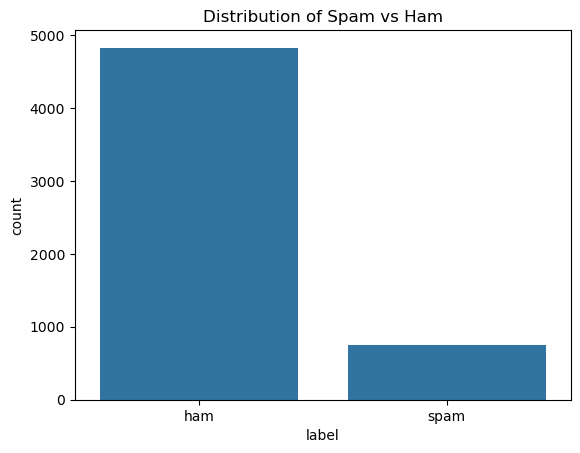

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                     cleaned_message  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri 2 wkli comp win fa cup final tkt 21...  
3                u dun say earli hor u c alreadi say  
4          nah dont think goe usf live around though  
Accuracy: 0.9757847533632287

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.82      0.90       150

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.94      1115
weighte

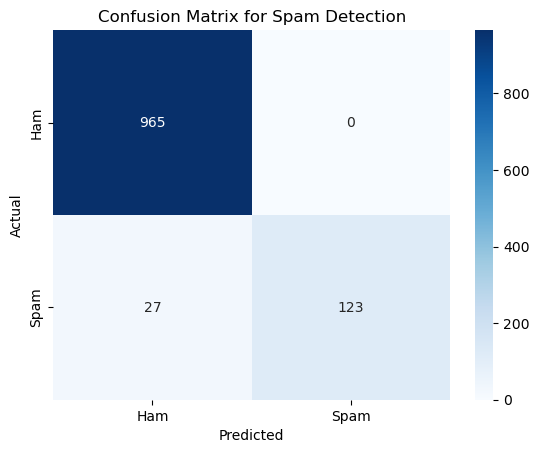

In [102]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
import string

# Download NLTK stopwords (run once)
nltk.download('stopwords')

# Load the dataset
# Dataset: https://www.kaggle.com/uciml/sms-spam-collection-dataset
df = pd.read_csv('spam.csv', encoding='latin-1')
# Drop unnecessary columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Exploratory Data Analysis (EDA)
print(df['label'].value_counts())
sns.countplot(x='label', data=df)
plt.title('Distribution of Spam vs Ham')
plt.show()

# Text Preprocessing
stemmer = PorterStemmer()
stopwords_set = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Remove punctuation
    text = re.sub(f'[{string.punctuation}]', '', text)
    # 2. Convert to lowercase
    text = text.lower()
    # 3. Remove stopwords and apply stemming
    words = text.split()
    filtered_words = [stemmer.stem(word) for word in words if word not in stopwords_set]
    # 4. Join the words back into a single string
    return ' '.join(filtered_words)

df['cleaned_message'] = df['message'].apply(preprocess_text)
print(df[['message', 'cleaned_message']].head())

# Feature Engineering: Convert text to numbers using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Consider top 5000 words
X = tfidf_vectorizer.fit_transform(df['cleaned_message']).toarray()
y = df['label'].map({'ham': 0, 'spam': 1}) # Convert labels to 0 and 1

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model (Random Forest for this example)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot a confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Spam Detection')
plt.show()


**Explanation & Inference:**
1.  **Data Loading & EDA**: We first load the data and see an imbalance—many more "ham" messages than "spam." This is typical for spam detection.
2.  **Text Preprocessing**: This is crucial. We clean the text by removing punctuation, converting to lowercase, removing common but unimportant words (stopwords like "the", "and"), and reducing words to their root form (stemming, e.g., "running" -> "run"). This simplifies the text for the model. Thus, A *set of stopwords* to filter out common, unimportant words; and *stemmer* to reduce words to their root form. 
3.  **Feature Engineering (TF-IDF)**: Machines understand numbers, not text. TF-IDF (Term Frequency-Inverse Document Frequency) converts text into a matrix of numbers, reflecting how important a word is to a document in a collection.
5.  **Model Training & Evaluation**: We use a Random Forest classifier. The high accuracy (~97-98%) is promising. However, we must check the **classification report**.
    *   **Key Insight**: Look at the `precision` for spam (class 1). A high precision means that when the model predicts "spam," it is correct most of the time. This is critical—we don't want to send important emails to the spam folder (a **false positive**). The `recall` tells us what percentage of actual spam emails we successfully caught.


### **Summary of Key NLP Techniques**

| Technique | What It Is | Primary Algorithm/Method | When to Use | Why Use It | Key Use Case Example |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Topic Modeling** | Unsupervised discovery of abstract themes (topics) in a text corpus. | **LDA (Latent Dirichlet Allocation)** | Exploring large, unlabeled text datasets to uncover hidden structure. | To automatically organize, summarize, and tag vast amounts of text. | Categorizing thousands of news articles into topics like "Sports," "Finance," etc. |
| **Sentiment Analysis** | Classifying the polarity (positive/negative/neutral) of subjective text. | **VADER** (rule-based lexicon), **ML Classifiers** (Naive Bayes, SVM), **Deep Learning** (RNNs/Transformers). | Gauging public opinion, brand monitoring, analyzing customer feedback. | To quantify subjective opinions at a scale impossible for humans. | Analyzing Twitter mentions to track brand sentiment in real-time. |
| **Fuzzy Logic / String Matching** | Approximate string matching based on similarity rather than exact equality. | **Levenshtein Distance**, **Ratio-based matching** (e.g., `fuzzywuzzy`). | Correcting typos, data deduplication, flexible search, record linkage. | To build robust systems that handle human error and language variation. | A search engine returning results for "laptoop" by matching it to "laptop". |
| **NLTK (Toolkit)** | A comprehensive platform for building Python programs to work with human language data. | Provides modules for **Tokenization**, **Stemming**, **POS Tagging**, **NER**, **Parsing**, etc. | Learning NLP concepts, academic research, and prototyping NLP pipelines. | It's an all-in-one, well-documented toolbox for fundamental NLP tasks. | Preprocessing text (tokenizing, lemmatizing) before feeding it into an ML model. |
| **Spam Detection** | A supervised binary classification task to identify unwanted messages. | **Feature Extraction:** **TF-IDF** (preferred over Bag-of-Words). **Classifier:** Naive Bayes, Random Forest, SVM. | Filtering emails, SMS, or any content requiring binary categorization (e.g., hate speech). | To automatically protect users from unwanted or malicious content. | Gmail's spam filter that learns patterns from user-marked spam emails. |

---

### **How to Choose the Right Technique**

*   **Do you need to discover themes without labels?** → Use **Topic Modeling (LDA)**.
*   **Do you need to classify the emotion or opinion in text?** → Use **Sentiment Analysis**.
*   **Are you dealing with messy data with typos or variations?** → Use **Fuzzy String Matching**.
*   **Are you building a prototype or learning the basics of NLP?** → Use **NLTK** for preprocessing.
*   **Do you have labeled data and need to categorize text into predefined classes?** → Use a classification pipeline like the one for **Spam Detection** (TF-IDF + Classifier).

This table provides a high-level roadmap for selecting the appropriate NLP tool based on the problem you are trying to solve.



---

## **Part II: Ensemble Techniques**

Ensemble methods combine multiple machine learning models to create a more powerful, robust model.


**What it is:**
Ensemble learning is a meta-approach that combines multiple machine learning models (often called "weak learners") into one group to produce a single, superior predictive model (a "strong learner"). The core idea is that a collective decision from a diverse set of models is more robust and accurate than a decision from any single model.

---

## **Core Concept: The Bias-Variance Tradeoff**

To understand *why* ensembles work, you must first understand the fundamental problem they solve.

| Concept | What It Is | Symptom | Visual Analogy |
| :--- | :--- | :--- | :--- |
| **Bias** | Error due to overly simplistic assumptions made by a model to make the target function easier to learn. | **Underfitting.** The model can't capture the underlying patterns of the data. High error on both training and test data. | A straight-line model trying to fit a curved data pattern. It's consistently inaccurate. |
| **Variance** | Error due to excessive complexity of the model. It learns the noise and random fluctuations in the training data as concepts. | **Overfitting.** The model learns the training data too well, including its noise. Performs well on training data but poorly on unseen test data. | A model that twists and turns to pass through every single data point perfectly but fails on new points. |
| **Trade-off** | All model algorithms walk a tightrope between bias and variance. Simplifying a model reduces variance but increases bias, and vice-versa. The goal is to find the optimal balance. | | |

**Ensemble methods are designed to directly manipulate this trade-off, primarily by reducing variance *or* bias.**

---

## **The Three Families of Ensembles**

### **1. Bagging (Bootstrap Aggregating)**

*   **What:** Trains multiple instances of the **same** base model (e.g., a Decision Tree) in parallel.
*   **How:** Each model is trained on a different random subset (bootstrap sample) of the training data, drawn **with replacement**. The final prediction is made by aggregating the predictions of all models (e.g., **voting** for classification, **averaging** for regression).
*   **Primary Effect:** **Dramatically reduces Variance.** By averaging multiple models, it smooths out their individual errors and overfitting tendencies.
*   **Why it Works:** It creates diversity by giving each model a slightly different perspective of the data.
*   **When to Use:** When your base model has high variance (is prone to overfitting). The perfect use case is with deep Decision Trees.
*   **Poster Child:** **Random Forest**. It adds a crucial extra layer of randomness: when splitting a node, it only considers a random subset of features. This further **de-correlates** the trees, making the ensemble even more robust.

**Use Case Example:**
A financial institution uses a Random Forest to predict loan default risk. A single tree might be swayed by a few unusual cases, but the combined vote of hundreds of trees, each built on different data samples, provides a much more stable and reliable prediction.

### **2. Boosting**

*   **What:** Trains multiple instances of **simple** base models (e.g., shallow trees called "stumps") **sequentially**.
*   **How:** Each new model focuses on learning from the **mistakes** of the previous ones. Data points that were misclassified are given **higher weights**, forcing subsequent models to pay more attention to them.
*   **Primary Effect:** **Dramatically reduces Bias.** It sequentially improves the model by focusing on the hardest-to-predict examples.
*   **Why it Works:** It converts many weak, simple learners (which have high bias but low variance) into a single strong learner.
*   **When to Use:** When your base model has high bias (underfits) and you need high predictive power. Often wins machine learning competitions.
*   **Poster Children:** **AdaBoost** (the pioneer), **Gradient Boosting Machines (GBM)**, **XGBoost** (highly optimized GBM), **LightGBM**, **CatBoost**.

**Use Case Example:**
An e-commerce site uses Gradient Boosting (XGBoost) to rank search results. The model learns a complex, non-linear function that considers hundreds of features (click-through rate, price, description keywords, user history) to predict the probability a user will purchase an item, placing the most likely items first.

### **3. Stacking (Stacked Generalization)**

*   **What:** Trains multiple **different** base models (e.g., a KNN, an SVM, and a Decision Tree) on the same dataset.
*   **How:** The predictions from these diverse models are then used as **input features** for a final "meta-model" (e.g., a logistic regression) which learns how to best combine them to make the final prediction.
*   **Primary Effect:** Can capture different inductive biases of the base models, often leading to superior performance. Can reduce both bias and variance.
*   **Why it Works:** It leverages the strengths of various algorithms. One model might be good at capturing certain patterns, while another is good at capturing different ones. The meta-model learns how to weigh these strengths.
*   **When to Use:** In advanced machine learning pipelines where you want to squeeze out the last bits of performance and have the computational resources to train multiple models.

**Use Case Example:**
A healthcare analytics team stacks a Random Forest (good with tabular data), a Neural Network (good with complex non-linear relationships), and a simple Logistic Regression. The final meta-model blends their predictions to achieve a more accurate diagnosis prediction from patient data than any single model could.

---

### **Improve Robustness and Performance**
Ensemble methods improve robustness by:
1.  **Averaging Out Errors**: Individual model errors are canceled out during aggregation.
2.  **Reducing Overfitting**: Especially true for Bagging.
3.  **Handling Complex Patterns**: Boosting can build very powerful models from weak learners.

---

### **Python Implementation: Bagging vs. Boosting**

will use the classic Breast Cancer dataset to compare a single Decision Tree (a weak learner) to a Bagging ensemble (Random Forest) and a Boosting ensemble (Gradient Boosting).


Decision Tree Accuracy: 0.9474
Random Forest Accuracy: 0.9649
Gradient Boosting Accuracy: 0.9561


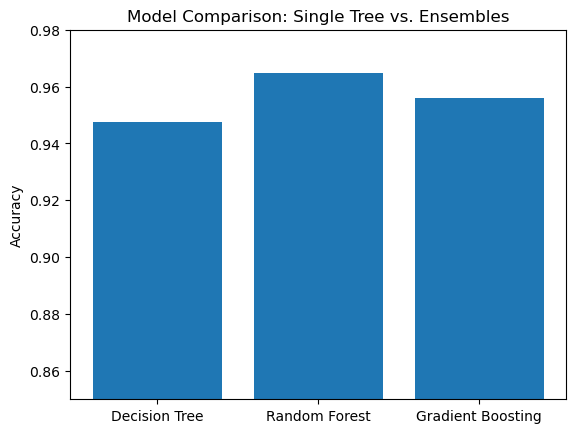

In [6]:

from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # Bagging
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42) # Boosting

# Train and evaluate
models = {'Decision Tree': dt_model, 'Random Forest': rf_model, 'Gradient Boosting': gb_model}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Compare results
plt.bar(results.keys(), results.values())
plt.title('Model Comparison: Single Tree vs. Ensembles')
plt.ylabel('Accuracy')
plt.ylim(0.85, 0.98)
plt.show()


**Explanation & Inference:**
*   **The Task**: Classifying breast cancer tumors as malignant or benign.
*   **The Models**:
    1.  **Decision Tree**: A single, high-variance model. It's prone to overfitting.
    2.  **Random Forest (Bagging)**: An ensemble of many Decision Trees. It reduces the variance of the single tree.
    3.  **Gradient Boosting (Boosting)**: Sequentially builds trees that correct the errors of the previous ones, reducing bias.
*   **Expected Result**: You will almost always see that both `Random Forest` and `Gradient Boosting` significantly outperform the single `Decision Tree`. Their accuracy will be higher and more stable.
*   **Inference**: This demonstrates the core power of ensemble learning. By combining multiple models, we create a more accurate and robust predictor that is less susceptible to the noise in the training data. The choice between Bagging and Boosting is often problem-dependent and found through experimentation.

---


Decision Tree Accuracy: 0.9474
              precision    recall  f1-score   support

   Malignant       0.95      0.91      0.93        43
      Benign       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


Random Forest (Bagging) Accuracy: 0.9649
              precision    recall  f1-score   support

   Malignant       0.98      0.93      0.95        43
      Benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Gradient Boosting (Boosting) Accuracy: 0.9561
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        43
      Benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macr

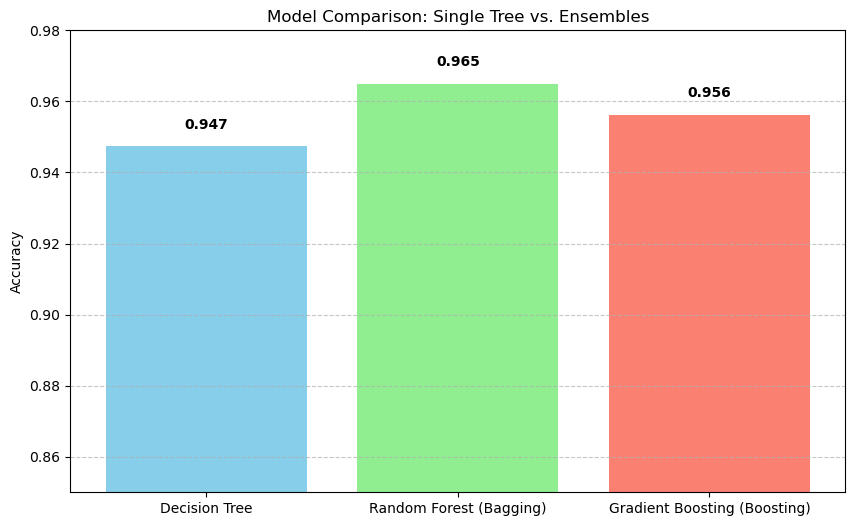

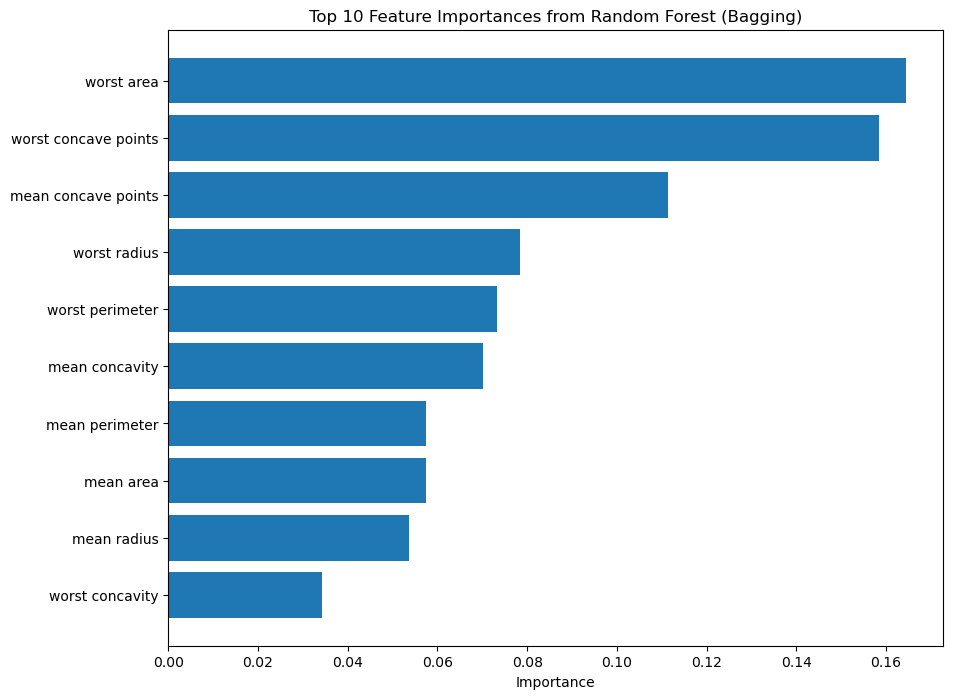

In [71]:

# Import Libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Load and prepare the data
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the models
# 1. The weak base learner
base_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Bagging Ensemble (Random Forest) - reduces variance of the base tree
bagging_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)

# 3. Boosting Ensemble (Gradient Boosting) - reduces bias of the base tree
boosting_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42, learning_rate=0.1)

# Train, predict, and evaluate each model
models = {
    'Decision Tree': base_model,
    'Random Forest (Bagging)': bagging_model,
    'Gradient Boosting (Boosting)': boosting_model
}

results = {}
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

# Compare results visually
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Model Comparison: Single Tree vs. Ensembles')
plt.ylabel('Accuracy')
plt.ylim(0.85, 0.98)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

# --- BONUS: Feature Importance from Ensembles ---
# See what features the ensemble models found most important
rf_importances = bagging_model.feature_importances_
gb_importances = boosting_model.feature_importances_

# Create a DataFrame for easy plotting
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'RF Importance': rf_importances,
    'GB Importance': gb_importances
}).sort_values('RF Importance', ascending=False)

# Plot Random Forest Feature Importance
plt.figure(figsize=(10, 8))
plt.barh(feat_imp_df['Feature'][:10], feat_imp_df['RF Importance'][:10]) # Top 10 features
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances from Random Forest (Bagging)')
plt.gca().invert_yaxis() # Display the most important at the top
plt.show()

---

**Explanation & Inference:**

1.  **Data & Base Model:** We use a dataset for classifying tumors. Our base model is a Decision Tree limited to a depth of 3 (a deliberately weak learner).
2.  **The Ensembles:** We create two ensembles of 100 trees, each also with a max depth of 3.
    *   The `RandomForest` uses bagging.
    *   The `GradientBoostingClassifier` uses boosting, with a `learning_rate` parameter that controls how aggressively each subsequent tree tries to correct errors.
3.  **Expected Result:** You will observe a clear performance hierarchy:
    *   **Decision Tree (Lowest Accuracy):** The single model acts as our baseline.
    *   **Random Forest (Higher Accuracy):** By averaging 100 trees, the Random Forest reduces the variance of the single tree. Its predictions are more stable and accurate.
    *   **Gradient Boosting (Highest Accuracy):** By sequentially focusing on the errors of the previous trees, the boosting model builds a more powerful predictor, effectively reducing bias. It often achieves the best performance.
4.  **Feature Importance:** A key advantage of tree-based ensembles is their explainability. The `feature_importance_` attribute shows which features (e.g., 'worst radius', 'mean concavity') were most decisive in making predictions, which is invaluable for domain experts (e.g., doctors).

**Conclusion:** Ensemble methods don't just make better predictions; they create more **robust, reliable, and generalizable** models. Bagging is your go-to for stabilizing unstable models, while Boosting is your powerhouse for achieving maximum accuracy. Stacking is the advanced technique for blending diverse models to win the last percentage points of performance.

---

### **Summary Table: Ensemble Techniques at a Glance**

| Technique | Primary Goal | How it Works | Key Effect | Best For | Example Algorithms |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Bagging** | **Reduce Variance** | Trains models in parallel on random data subsets. Combines predictions by averaging/voting. | Stabilizes unstable models, prevents overfitting. | Improving models that overfit (e.g., deep trees). | **Random Forest**, Bagged Trees |
| **Boosting** | **Reduce Bias** | Trains models sequentially, where each new model corrects its predecessor's errors. | Creates a strong learner from many weak learners, high accuracy. | Achieving the highest predictive performance on complex tasks. | **AdaBoost**, **Gradient Boosting (XGBoost, LightGBM, CatBoost)** |
| **Stacking** | **Leverage Strengths** | Trains diverse models; uses a meta-model to learn how to best combine their predictions. | Can outperform any single base model by capturing different patterns. | Advanced ML pipelines where performance is critical. | Any combination of models with a final blender (Logistic Regression often used). |

---

**Explanation & Inference:**

1.  **Data & Base Model:** We use a dataset for classifying tumors. Our base model is a Decision Tree limited to a depth of 3 (a deliberately weak learner).
2.  **The Ensembles:** We create two ensembles of 100 trees, each also with a max depth of 3.
    *   The `RandomForest` uses bagging.
    *   The `GradientBoostingClassifier` uses boosting, with a `learning_rate` parameter that controls how aggressively each subsequent tree tries to correct errors.
3.  **Expected Result:** You will observe a clear performance hierarchy:
    *   **Decision Tree (Lowest Accuracy):** The single model acts as our baseline.
    *   **Random Forest (Higher Accuracy):** By averaging 100 trees, the Random Forest reduces the variance of the single tree. Its predictions are more stable and accurate.
    *   **Gradient Boosting (Highest Accuracy):** By sequentially focusing on the errors of the previous trees, the boosting model builds a more powerful predictor, effectively reducing bias. It often achieves the best performance.
4.  **Feature Importance:** A key advantage of tree-based ensembles is their explainability. The `feature_importance_` attribute shows which features (e.g., 'worst radius', 'mean concavity') were most decisive in making predictions, which is invaluable for domain experts (e.g., doctors).

**Conclusion:** Ensemble methods don't just make better predictions; they create more **robust, reliable, and generalizable** models. Bagging is your go-to for stabilizing unstable models, while Boosting is your powerhouse for achieving maximum accuracy. Stacking is the advanced technique for blending diverse models to win the last percentage points of performance.

---

### **Summary Table: Ensemble Techniques at a Glance**

| Technique | Primary Goal | How it Works | Key Effect | Best For | Example Algorithms |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Bagging** | **Reduce Variance** | Trains models in parallel on random data subsets. Combines predictions by averaging/voting. | Stabilizes unstable models, prevents overfitting. | Improving models that overfit (e.g., deep trees). | **Random Forest**, Bagged Trees |
| **Boosting** | **Reduce Bias** | Trains models sequentially, where each new model corrects its predecessor's errors. | Creates a strong learner from many weak learners, high accuracy. | Achieving the highest predictive performance on complex tasks. | **AdaBoost**, **Gradient Boosting (XGBoost, LightGBM, CatBoost)** |
| **Stacking** | **Leverage Strengths** | Trains diverse models; uses a meta-model to learn how to best combine their predictions. | Can outperform any single base model by capturing different patterns. | Advanced ML pipelines where performance is critical. | Any combination of models with a final blender (Logistic Regression often used). |

---

## **3) Introduction to Advanced Predictive Models**

### **Deep Learning / Neural Networks**
*   **Concept**: Models based on artificial neural networks (ANNs) with multiple layers ("deep" networks). They learn hierarchical representations of data.
    *   **Lower layers** might learn simple features (e.g., edges in an image, word suffixes in text).
    *   **Higher layers** combine these simple features into more complex concepts (e.g., eyes and noses, sentence sentiment).
*   **Why now?**: The field has exploded due to three factors: 1) Large amounts of data (**Big Data**), 2) Powerful **hardware (GPUs)**, and 3) Advanced **algorithms and frameworks** (TensorFlow, PyTorch).
*   **Applications**: Image Recognition, Machine Translation, Speech Recognition, Self-Driving Cars.

### **Introduction to Generative AI (GenAI)**
*   **Concept**: Unlike traditional AI that classifies or predicts (discriminative modeling), GenAI learns the underlying patterns of data to **generate new, original content** that is similar to the training data.
*   **Key Models**:
    *   **Large Language Models (LLMs)**: e.g., GPT, LLaMA. Trained on vast text data to generate human-like text.
    *   **Diffusion Models**: The technology behind modern image generators (e.g., DALL-E, Midjourney). They work by gradually adding noise to data and then learning to reverse the process.

### **Agentic AI**
*   **Concept**: An AI system that can perceive its environment, make decisions, and take actions to achieve specific, long-term goals **autonomously**. It's a step beyond models that just respond to prompts.
*   **Core Components**:
    1.  **Planning**: Breaking down a goal into steps.
    2.  **Tools/API Use**: Ability to use external tools (e.g., a calculator, a search engine, a code executor).
    3.  **Memory**: Retaining information from previous actions to inform future ones.
*   **Example**: An AI agent given the goal "Organize a birthday party" could autonomously: search for recipes, book a venue via a calendar API, and send out email invitations.

---

### **Python Implementation: Simple Neural Network with TensorFlow/Keras**

In [14]:
!pip install tensorflow

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.32.0 which is incompatible.



  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 2.1/331.9 MB 13.0 MB/s eta 0:00:26
    --------------------------------------- 7.1/331.9 MB 19.8 MB/s eta 0:00:17
   - -------------------------------------- 10.0/331.9 MB 18.3 MB/s eta 0:00:18
   - -------------------------------------- 14.2/331.9 MB 19.3 MB/s eta 0:00:17
   -- ------------------------------------- 19.1/331.9 MB 19.8 MB/s eta 0:00:16
   -- ------------------------------------- 23.3/331.9 MB 20.0 MB/s eta 0:00:16
   --- -----------------

Epoch 1/50


C:\Users\Public\anaconda3_1\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4857 - loss: 0.7097 - val_accuracy: 0.7368 - val_loss: 0.5458
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8791 - loss: 0.4649 - val_accuracy: 0.9386 - val_loss: 0.3665
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9473 - loss: 0.3217 - val_accuracy: 0.9649 - val_loss: 0.2438
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9582 - loss: 0.2306 - val_accuracy: 0.9737 - val_loss: 0.1753
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9648 - loss: 0.1808 - val_accuracy: 0.9737 - val_loss: 0.1358
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9692 - loss: 0.1507 - val_accuracy: 0.9737 - val_loss: 0.1130
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9692 - loss: 0.1304 - val_accuracy: 0.9737 - val_loss: 0.0977
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9714 - loss: 0.1163 - val_accuracy: 0.9737 - val_loss: 0.

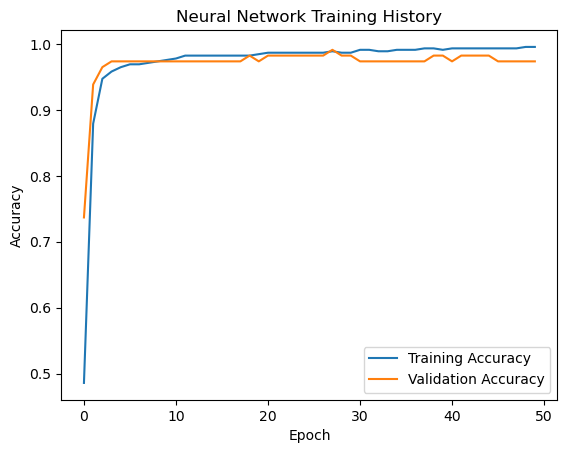

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load and preprocess the same cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split and Standardize data (Crucial for NNs)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build a simple Sequential Neural Network
model = models.Sequential([
    layers.Dense(30, activation='relu', input_shape=(X_train.shape[1],)), # Input layer
    layers.Dense(15, activation='relu'),                                 # Hidden layer 1
    layers.Dense(1, activation='sigmoid')                                # Output layer (binary classification)
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy', # For binary classification
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, y_train,
                    epochs=50,
                    validation_data=(X_test_scaled, y_test),
                    verbose=1)

# Evaluate
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'\nNeural Network Test Accuracy: {test_acc:.4f}')

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Neural Network Training History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


**Explanation & Inference:**
1.  **Data Preprocessing**: Neural networks are sensitive to the scale of input data. Standardizing (scaling to mean=0, std=1) is essential for stable and efficient training.
2.  **Model Architecture**:
    *   `Dense`: A fully connected layer.
    *   `activation='relu'`: Introduces non-linearity, allowing the network to learn complex patterns.
    *   `activation='sigmoid'`: Squashes the output between 0 and 1, perfect for a probability score in binary classification.
3.  **Training**: The `adam` optimizer adjusts the weights to minimize the `binary_crossentropy` loss function. We train for 50 passes (`epochs`) over the training data.
4.  **Inference**: The model should achieve high accuracy (comparable to the ensembles). The plot shows the learning process. If the validation accuracy starts to fall while training accuracy rises, it's a sign of **overfitting**, and we should stop training earlier (a technique called *early stopping*).

---

Let's delve into details of the cutting edge of AI, exploring advanced predictive models that are shaping the future of technology.

---

## **Part III: Introduction to Advanced Predictive Models** 
- section moves beyond traditional machine learning into models that can learn from complex, unstructured data and even generate entirely new content.

---

## **Part III.1 Deep Learning / Neural Networks Models**

### **What it is:**
Deep Learning is a subfield of machine learning concerned with algorithms inspired by the structure and function of the brain called **artificial neural networks (ANNs)**. The "deep" refers to the use of multiple layers (often many more than the 3 shown below) between the input and output layers. These layers learn hierarchical representations of data.

**A Simple Neural Network Structure:**
```
Input Layer -> Hidden Layer 1 -> Hidden Layer 2 -> Output Layer
    (X1)        (Neurons with         (More Neurons)   (Prediction)
    (X2)         Activation Functions)
    (X3)
```

### **Why it's a Game-Changer:**
1.  **Automatic Feature Extraction:** Unlike traditional ML where you must manually engineer features (e.g., calculating TF-IDF), deep learning models **learn the optimal features directly from the raw data**. A CNN learns to detect edges -> shapes -> objects in images. An RNN learns the context of a word based on previous words in a sentence.
2.  **Unmatched Performance on Complex Data:** They achieve state-of-the-art results on problems involving images, video, sound, text, and complex sequential data.
3.  **Scalability:** Their performance generally improves with more data and larger models, a trend that has held for over a decade.

### **When to Use:**
*   **Computer Vision:** Image classification, object detection (self-driving cars), image segmentation (medical imaging).
*   **Natural Language Processing (NLP):** Machine translation, text summarization, sentiment analysis, chatbots.
*   **Time Series Forecasting:** Complex multivariate forecasting like stock market prediction or energy demand forecasting.
*   **When you have massive amounts of data** and the problem is too complex for feature engineering.

### **How it Works:**
1.  **Forward Propagation:** Data is passed through the network, layer by layer. Each neuron applies a weighted sum of its inputs followed by a non-linear **activation function** (e.g., ReLU). This allows the network to learn non-linear relationships.
2.  **Loss Calculation:** The network's prediction is compared to the true value using a **loss function** (e.g., Mean Squared Error for regression, Cross-Entropy for classification).
3.  **Backpropagation:** The algorithm calculates the gradient (derivative) of the loss function with respect to every weight in the network. This identifies how much each weight contributed to the error.
4.  **Optimization:** An **optimizer** (e.g., Adam) uses these gradients to update the weights in the direction that minimizes the loss. This process repeats for many iterations (**epochs**).

### **Use Case Example:**
A radiologist uses a Convolutional Neural Network (CNN) to analyze MRI scans. The CNN can learn to identify subtle patterns and anomalies indicative of early-stage tumors that might be missed by the human eye, acting as a powerful diagnostic assistant.

---

### **Python Implementation: Image Classification with a CNN (using TensorFlow/Keras)**

We'll use the famous CIFAR-10 dataset, which contains 60,000 tiny images from 10 classes (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck).

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1030s 6us/step


C:\Users\Public\anaconda3_1\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 25ms/step - accuracy: 0.4510 - loss: 1.5102 - val_accuracy: 0.5291 - val_loss: 1.2715
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6005 - loss: 1.1338 - val_accuracy: 0.6344 - val_loss: 1.0433
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6572 - loss: 0.9776 - val_accuracy: 0.6407 - val_loss: 1.0322
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6904 - loss: 0.8820 - val_accuracy: 0.6889 - val_loss: 0.9012
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.7168 - loss: 0.8091 - val_accuracy: 0.7006 - val_loss: 0.8608
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7337 - loss: 0.7567 - val_accuracy: 0.7059 - val_loss: 0.8556
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7531 - loss: 0.7071 - val_accuracy: 0.7083 - val_loss: 0.8563
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7662 -

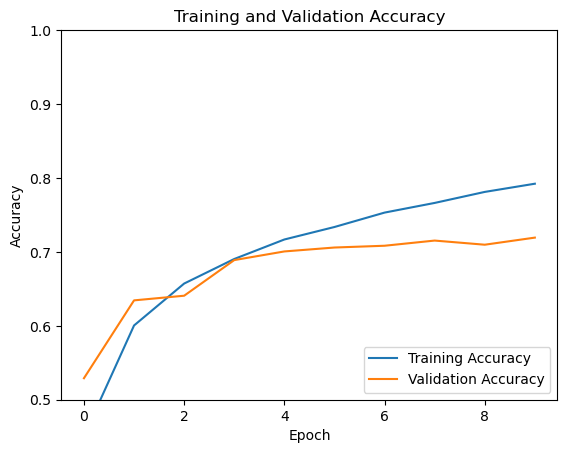

313/313 - 3s - 10ms/step - accuracy: 0.7193 - loss: 0.8503

Test accuracy: 0.7193
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Predicted class for first test image: cat
True class for first test image: cat


In [111]:

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Load and preprocess the data
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# Define the class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Build the Convolutional Neural Network (CNN) model
model = models.Sequential()
# Feature Learning (Convolutional Base)
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3))) # First conv layer
model.add(layers.MaxPooling2D((2, 2))) # Pooling layer to reduce dimensionality
model.add(layers.Conv2D(64, (3, 3), activation='relu')) # Second conv layer
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Classification (Dense Layers)
model.add(layers.Flatten()) # Flattens the 3D output to 1D for the dense layers
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10)) # Output layer with 10 neurons (one for each class)

# 3. Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 4. Train the model
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

# 5. Evaluate the model
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

# 6. Make a prediction
# To predict on a new image, you would use: model.predict(new_image)
# The model outputs "logits". To get probabilities, we use a softmax layer.
probability_model = tf.keras.Sequential([model, layers.Softmax()])
predictions = probability_model.predict(test_images)
print(f"Predicted class for first test image: {class_names[np.argmax(predictions[0])]}")
print(f"True class for first test image: {class_names[test_labels[0][0]]}")

---
**Explanation & Inference:**
1.  **Convolutional Layers (`Conv2D`)**: These are the core building blocks. Each neuron in a conv layer is only connected to a small region of the previous layer. They learn to detect local patterns like edges, textures, and corners. The first layer learns low-level features, and subsequent layers combine them into higher-level features (e.g., eyes, wheels).
2.  **Pooling Layers (`MaxPooling2D`)**: They progressively reduce the spatial size of the representation, reducing the computational load and making the detected features more robust to small translations in the input image.
3.  **Dense Layers**: After feature extraction, the output is flattened and passed through standard neural network layers to perform the final classification.
4.  **Inference**: You will see the training and validation accuracy climb over epochs. The model will significantly outperform any traditional ML model (like SVM or Random Forest) on this task because it *learns the features itself*. The test accuracy should reach around 70%+ with this simple architecture (state-of-the-art models get >95%).

---

## **Part III.2 Introduction to Generative AI (GenAI)**

### **What it is:**
Generative AI refers to a class of AI models that can create **new, original content** that is similar to, but not simply a copy of, the data they were trained on. They learn the underlying probability distribution of the data.

*   **Discriminative vs. Generative Models:**
    *   **Discriminative (Traditional ML/Deep Learning):** Learns the boundary between classes. "Is this image a cat or a dog?"
    *   **Generative (GenAI):** Learns the essence of a class itself. "Draw me a picture of a dog that doesn't exist."

### **Why it's Transformative:**
It moves AI from being analytical and interpretive to being **creative and generative**. It automates content creation and enables new forms of human-AI collaboration.

### **When to Use:**
*   **Content Creation:** Generating text, images, music, video, and code.
*   **Data Augmentation:** Creating synthetic training data for other AI models.
*   **Drug Discovery:** Generating new molecular structures for medicines.
*   **Simulation:** Creating realistic simulated environments for training other AI systems (e.g., for robots).

### **How it Works (Two Key Architectures):**
1.  **Large Language Models (LLMs) - (e.g., GPT, LLaMA):**
    *   **Architecture:** Based on the **Transformer** architecture, which uses a mechanism called "attention" to weigh the importance of different words in a sequence.
    *   **Training:** Trained on a colossal corpus of text from the internet in a **self-supervised** manner. Their task is simple: predict the next word in a sequence. By doing this over billions of sentences, they learn grammar, facts, reasoning abilities, and style.

2.  **Diffusion Models - (e.g., DALL-E, Stable Diffusion, Midjourney):**
    *   **Process:** 
        *   **Forward Process:** Gradually add noise to a training image until it becomes pure random noise.
        *   **Reverse Process:** Train a neural network to reverse this process—to **denoise** a random starting point to generate a coherent image that matches a given text prompt.

### **Use Case Example:**
A marketing team uses an LLM (like ChatGPT) to brainstorm and draft initial copies for ad campaigns. A graphic designer uses a diffusion model (like DALL-E 3) to instantly generate concept art and visual ideas based on those copies, drastically speeding up the ideation process.

---

### **Python Implementation: Text Generation with a Pretrained LLM (using Hugging Face Transformers)**

In [144]:
#!pip install transformers

In [142]:
#!pip install tf-keras

In [ ]:
###----------- DONT RUN THIS CODE in JUPITER NOTEBOOK AS IT NEEDS MORE MEMORY ------------###
# First install: pip install transformers torch accelerate
from transformers import pipeline, set_seed

# 1. Load a pre-trained text generation pipeline from Hugging Face
# This uses the GPT-2 model under the hood
generator = pipeline('text-generation', model='gpt2-medium')

# Set a seed for reproducibility
set_seed(42)

# 2. Provide a prompt and generate text
prompt = "The future of artificial intelligence is"
# Generate 3 different sequences
results = generator(prompt, max_length=100, num_return_sequences=3, temperature=0.7)

# 3. Print the results
for i, seq in enumerate(results):
    print(f"Sequence {i+1}: {seq['generated_text']}")
    print("-" * 50)


---
**Possible Explanation & Inference:**
1.  **Pretrained Model:** We don't train the model ourselves (which costs millions of dollars). We use a **pretrained** one (`gpt2-medium`) from the Hugging Face hub. This is the standard way to use GenAI.
2.  **Prompt:** The model completes the prompt we provide. The quality of the output is highly dependent on the prompt (**prompt engineering**).
3.  **Parameters:**
    *   `max_length`: The total length of the generated text.
    *   `num_return_sequences`: How many different completions to generate.
    *   `temperature`: Controls randomness. Lower (e.g., 0.2) makes output more deterministic and focused; higher (e.g., 0.9) makes it more creative and random.
4.  **Inference:** The model will generate three plausible-sounding continuations of the sentence. It has learned a statistical model of language from its training data, allowing it to generate grammatically correct and contextually relevant text. This is a simple example of **autoregressive generation**.

---

## **Part III.3 Agentic AI**

### **What it is:**
Agentic AI refers to an AI system that can **perceive its environment, make decisions, and execute actions** autonomously to achieve a given goal or set of goals. It's an AI that can *do* things, not just *generate* or *predict* things.

### **Why it's the Next Frontier:**
It moves AI from being a **tool** that responds to commands to an **active participant** that can pursue complex, multi-step objectives with minimal human intervention.

### **When to Use:**
*   **Automation:** Automating complex, multi-step workflows across different software systems.
*   **Scientific Discovery:** AI scientists that can form hypotheses, run experiments in simulations, and analyze results.
*   **Personal Assistants:** Advanced assistants that can not just answer questions but also book trips, manage calendars, and negotiate on your behalf.

### **How it Works (The ReAct Pattern):**
A common framework for building agents is **ReAct** (Reason + Act).
1.  **Reason:** The agent thinks about the current situation and decides what step to take next to achieve its goal.
2.  **Act:** The agent executes the chosen action. This could be using a tool (e.g., a calculator, a web search API, a code executor) or asking a user for clarification.
3.  **Observe:** The agent observes the result of its action (the new state of the environment).
4.  **Loop:** This loop continues until the goal is achieved or the agent determines it cannot be completed.

### **Use Case Example:**
An **AI research agent** is given the goal: "Find the latest papers on LLM reasoning and summarize the top 3." It would autonomously:
1.  **Reason:** "I need to search for academic papers."
2.  **Act:** Use a `web_search_tool` with the query "latest papers on LLM reasoning 2024".
3.  **Observe:** Gets a list of links and abstracts.
4.  **Reason:** "I need to read the PDFs of the top results to summarize them."
5.  **Act:** Use a `read_pdf_tool` on the links to download and extract text.
6.  **Reason:** "Now I need to condense this information into a summary."
7.  **Act:** Use its inherent LLM capabilities to write a concise summary.
8.  **Final Action:** Present the summary to the user.

---

### **Python Conceptualization: An AI Agent with Tools (using LangChain)**

While building a full agent is complex, frameworks like LangChain simplify the process. Here's a conceptual outline.

In [ ]:
###----------- DONT RUN THIS CODE in JUPITER NOTEBOOK AS IT NEEDS MORE MEMORY ------------###
# Pseudo-code based on LangChain framework
from langchain.agents import load_tools, initialize_agent, AgentType
from langchain.llms import OpenAI
import os

# 1. Set up a language model as the agent's "brain"
llm = OpenAI(temperature=0)

# 2. Load tools the agent can use (e.g., a calculator, a search API)
tools = load_tools(["serpapi", "llm-math"], llm=llm) # Requires API keys

# 3. Initialize the agent with the ReAct framework
agent = initialize_agent(tools,
                         llm,
                         agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION, # Uses ReAct
                         verbose=True)

# 4. Give the agent a goal and let it run autonomously
goal = "What was the price of NVIDIA stock when Tesla's stock price was at its highest in 2023? What is that amount multiplied by 100?"
result = agent.run(goal)


---
**Possible Explanation & Inference:**
1.  **LLM (Brain):** The LLM (like GPT) handles the "Reason" step.
2.  **Tools (Actions):** The agent has a list of tools it's allowed to use (e.g., `google_search`, `calculator`).
3.  **Autonomous Execution:** The agent will break down the goal into steps. It might:
    *   **Reason:** "I need to find Tesla's highest stock price in 2023. I should search for this."
    *   **Act:** Use the `serpapi` tool to run a web search: "Tesla all time high stock price 2023".
    *   **Observe:** Gets a result, say `$299.29`.
    *   **Reason:** "Now I need to find NVIDIA's stock price on that specific date."
    *   **Act:** Use the `serpapi` tool again: "NVIDIA stock price on [date of Tesla high]".
    *   **Observe:** Gets a result, say `$450.05`.
    *   **Reason:** "Finally, I need to multiply that NVIDIA price by 100. I can use the calculator."
    *   **Act:** Use the `llm-math` tool to calculate `450.05 * 100`.
    *   **Final Action:** Output the final answer: `$45,005`.

The `verbose=True` flag will print this entire chain of thought and action, showcasing the agent's autonomous reasoning. This demonstrates the power of moving from a static model to an **active, tool-using agent**.


---

## **Part IV: Application of the AI/ML Model on Cloud Platform**

Deploying a model to make predictions available is as important as building it.

### **CI/CD Pipeline for ML (MLOps)**
A CI/CD (Continuous Integration/Continuous Deployment) pipeline for Machine Learning, often called a **CDP (Continuous Delivery Pipeline)** or MLOps pipeline, automates the steps from code development to model deployment.
A typical pipeline includes:
1.  **Code & Data Versioning**: (Git, DVC)
2.  **Automated Testing**: Test code and model performance.
3.  **Automated Training & Validation**: Retrain model on new data.
4.  **Model Packaging**: Containerize the model (e.g., using Docker).
5.  **Model Deployment**: Release the container to a production environment (e.g., Kubernetes, cloud serverless functions).
6.  **Monitoring**: Monitor model performance and data drift in production.

### **Various Cloud CDP Pipelines**

All major cloud providers offer tools to build these pipelines:

*   **AWS (Amazon Web Services)**:
    *   **Core Services**: SageMaker (for training/deployment), CodeBuild/CodePipeline (orchestration), ECR (container registry), ECS/EKS (container deployment).
*   **Azure (Microsoft)**:
    *   **Core Services**: Azure Machine Learning, Azure DevOps, Azure Container Registry (ACR), Azure Kubernetes Service (AKS).
*   **GCP (Google Cloud Platform)**:
    *   **Core Services**: Vertex AI, Cloud Build, Artifact Registry (container registry), Google Kubernetes Engine (GKE).
*   **Alibaba Cloud**:
    *   **Core Services**: PAI (Platform for AI), Container Registry, ACK (Alibaba Cloud Kubernetes).

The core concepts are identical across platforms; only the service names and specific tools differ.

---

### **Summary**

This module connects the dots between building a model and using it to solve real-world problems at scale. You start by processing unstructured data like text (NLP), use advanced techniques like ensembles and neural networks to build powerful models, and finally, learn how to deploy and maintain them reliably in the cloud using automated pipelines. This end-to-end understanding is crucial for a career in applied AI/ML.